# Pregunta de negoci:
## Analista de Màrqueting i Estratègia Comercial: 
- Quin és el preu mitjà dels allotjaments per tipus d'allotjament a cada ciutat?

### Details
* identificar el preu mitjà per tipus d’allotjament a cada ciutat 
* detectar oportunitats comercials 
* segmentar clients 
* definir estratègies de pricing 
* millorar posicionament de mercat 
* construir dashboards executius fiables 


### Tools

#### Libraries

In [20]:
#_____________________________________________________
from dotenv import load_dotenv
import os 
load_dotenv()  # reads .env file
#_____________________________________________________
from pathlib import Path

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from IPython.display import display, HTML, Image as IPyImage


#### Data

In [4]:
def get_notebook_dir():
    """Gets the directory of the current Jupyter notebook or Python script."""
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if '__file__' in globals() else Path.cwd()

# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the 'Data' folder
# Structure: ../Data/
raw_dir = notebook_dir.parent / 'Data'

# 3. Find the first .parquet file in that directory
parquet_files = list(raw_dir.glob('*_limpio.parquet'))

if not parquet_files:
    raise FileNotFoundError(f"No _limpio.parquet files found in: {raw_dir}")

# If you expect only one .parquet file, use the first (and only) one
parquet_path = parquet_files[0]

# 4. Load the data
alojamentos_df = pd.read_parquet(parquet_path)

print(f"Successfully loaded data from: {parquet_path}")

Successfully loaded data from: f:\_LearningMaterials\BarcelonaActiva\Simulació Empresarial\eq29_alojturistico\ProjecteData\Equip_29\Data\2026_05_25_pisos_turisticos_limpio.parquet


In [ ]:
# Data structure preview
alojamentos_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6733 entries, 0 to 6732
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 6733 non-null   int64         
 1   name                         6730 non-null   object        
 2   description                  6706 non-null   object        
 3   host_id                      6733 non-null   int64         
 4   neighbourhood_name           6733 non-null   object        
 5   neighbourhood_district       4075 non-null   object        
 6   room_type                    6733 non-null   object        
 7   accommodates                 6733 non-null   int64         
 8   bathrooms                    6733 non-null   float64       
 9   bedrooms                     6733 non-null   float64       
 10  beds                         6733 non-null   float64       
 11  amenities_list               6717 non-null   obj

<Axes: >

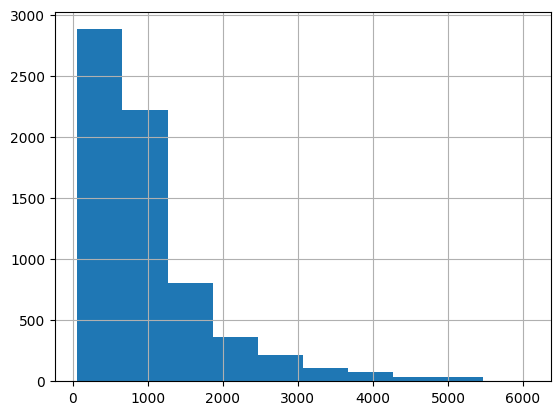

In [ ]:
# Price values distribution preview
alojamentos_df["price"].hist()

<Axes: >

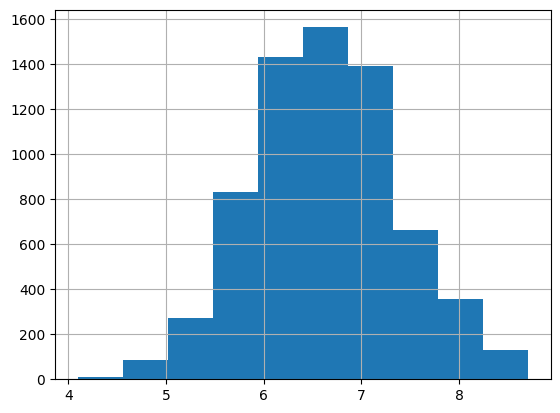

In [ ]:
# Price values LOG transformation for normal distribution preview
np.log(alojamentos_df["price"]).hist()

In [12]:
alojamentos_df["price_log"] = np.log(alojamentos_df["price"])

In [18]:
# Verify correlation of the transformed values
#Statistical reporting Block
sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Heuristic type classification for correlation selection.
    numeric   -> continuous numeric
    ordinal   -> integer-like / low-cardinality numeric
    categorical -> object/category/bool
    datetime  -> datetime
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Full one-field workflow:
    1) plots
    2) summary statistics table
    3) unique values table
    4) correlation table with all other fields
    5) transformation skewness table
    6) saves csv outputs
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }


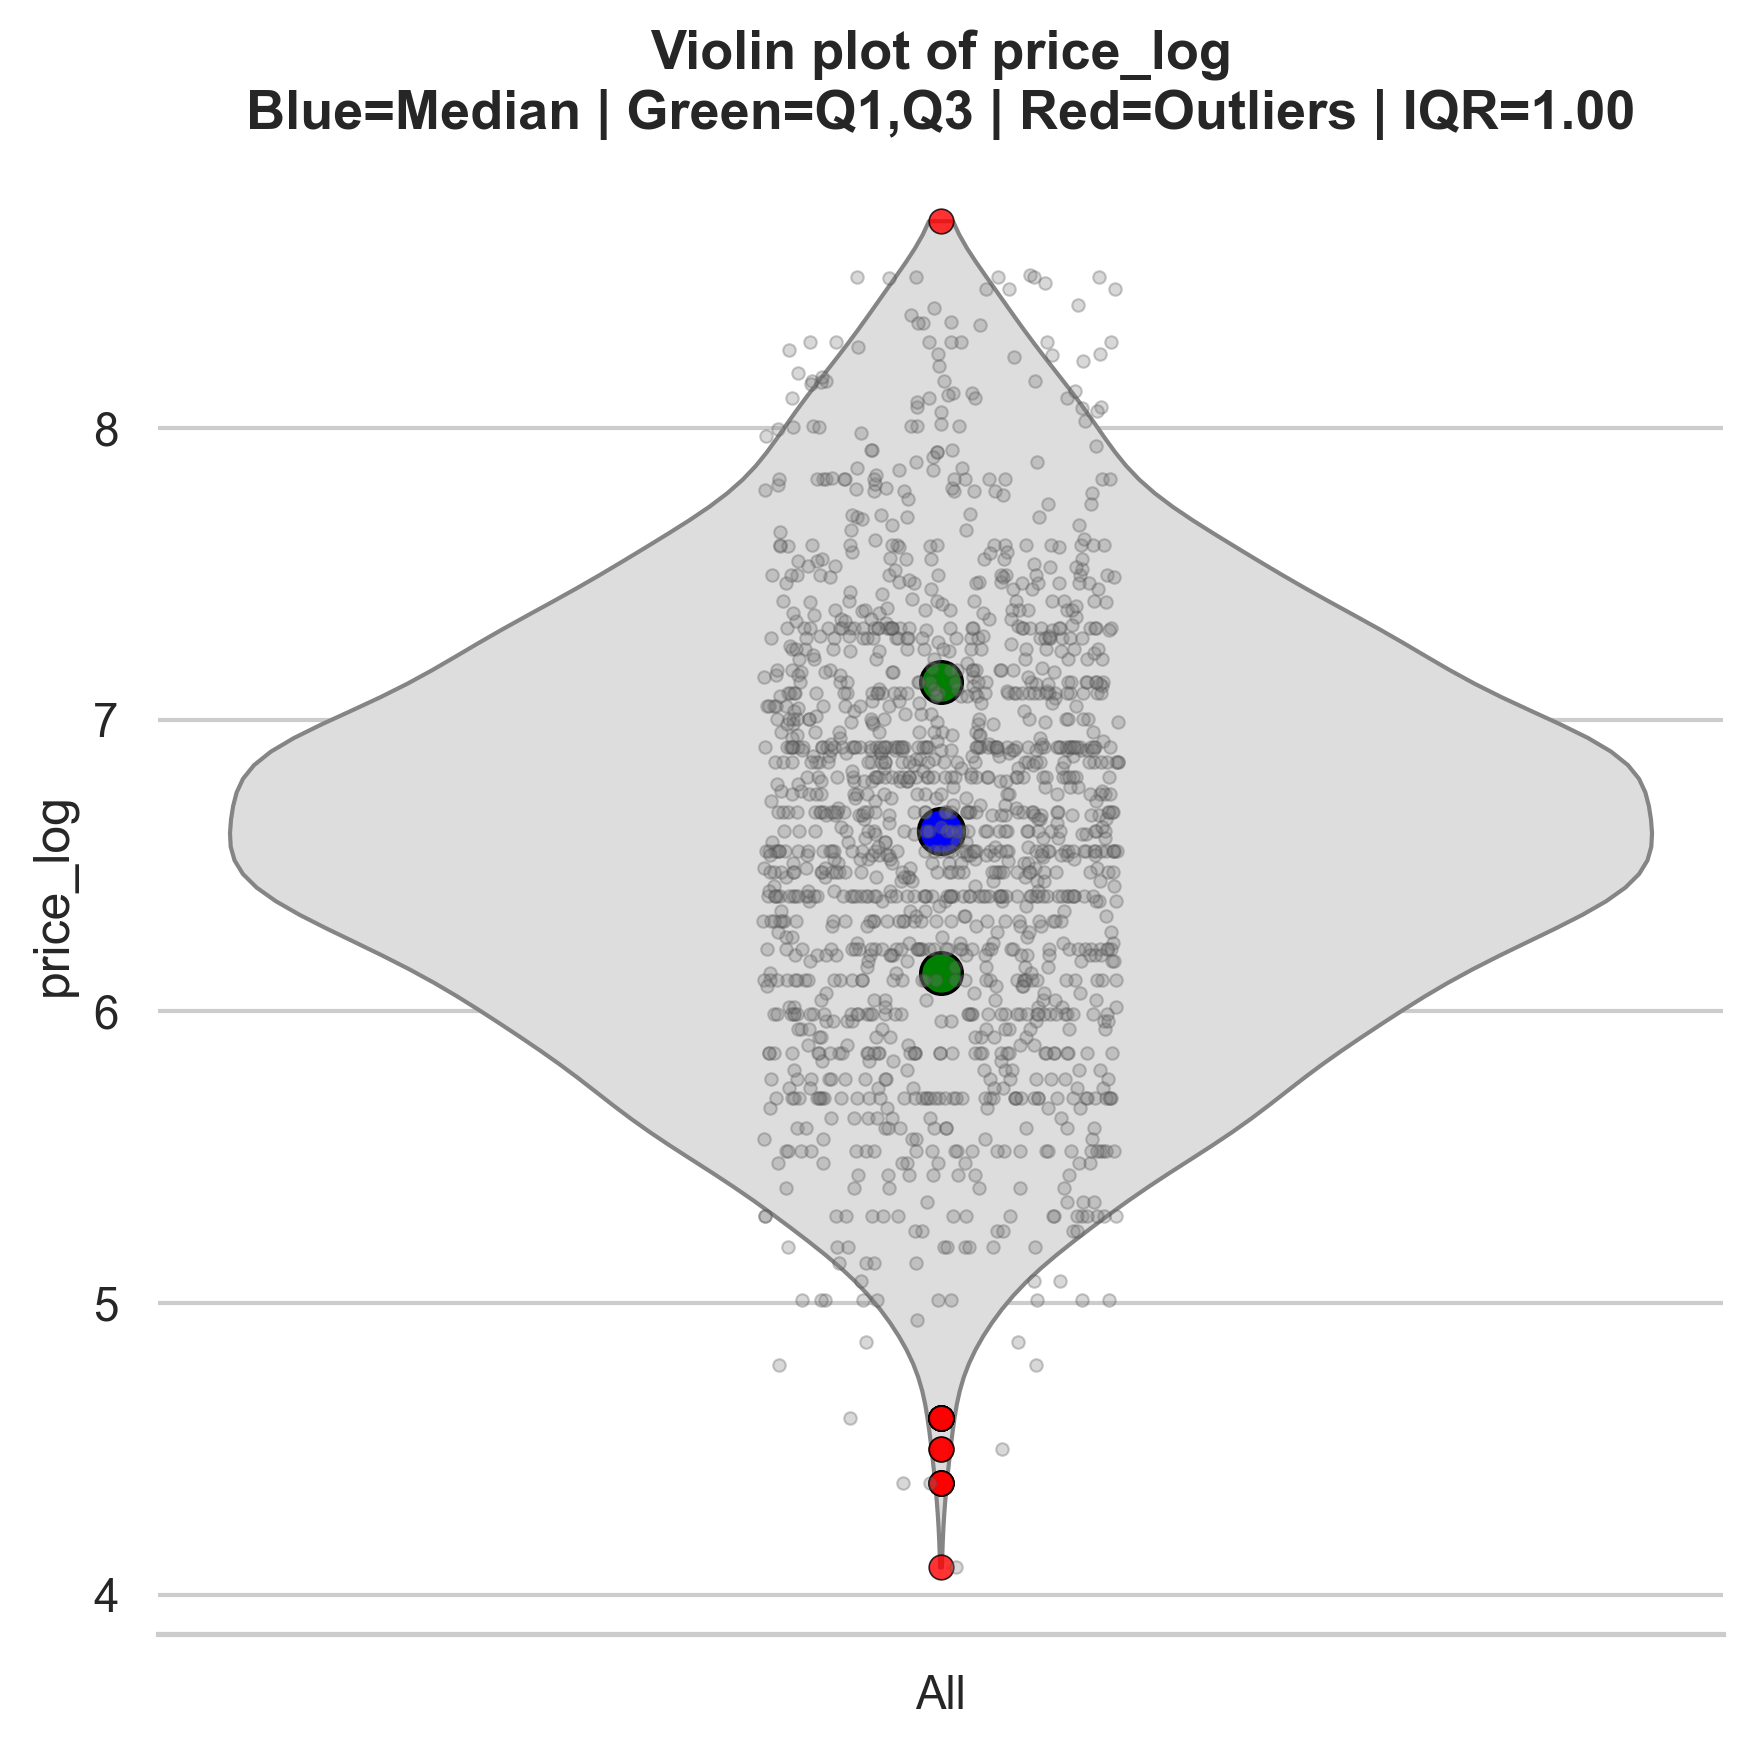

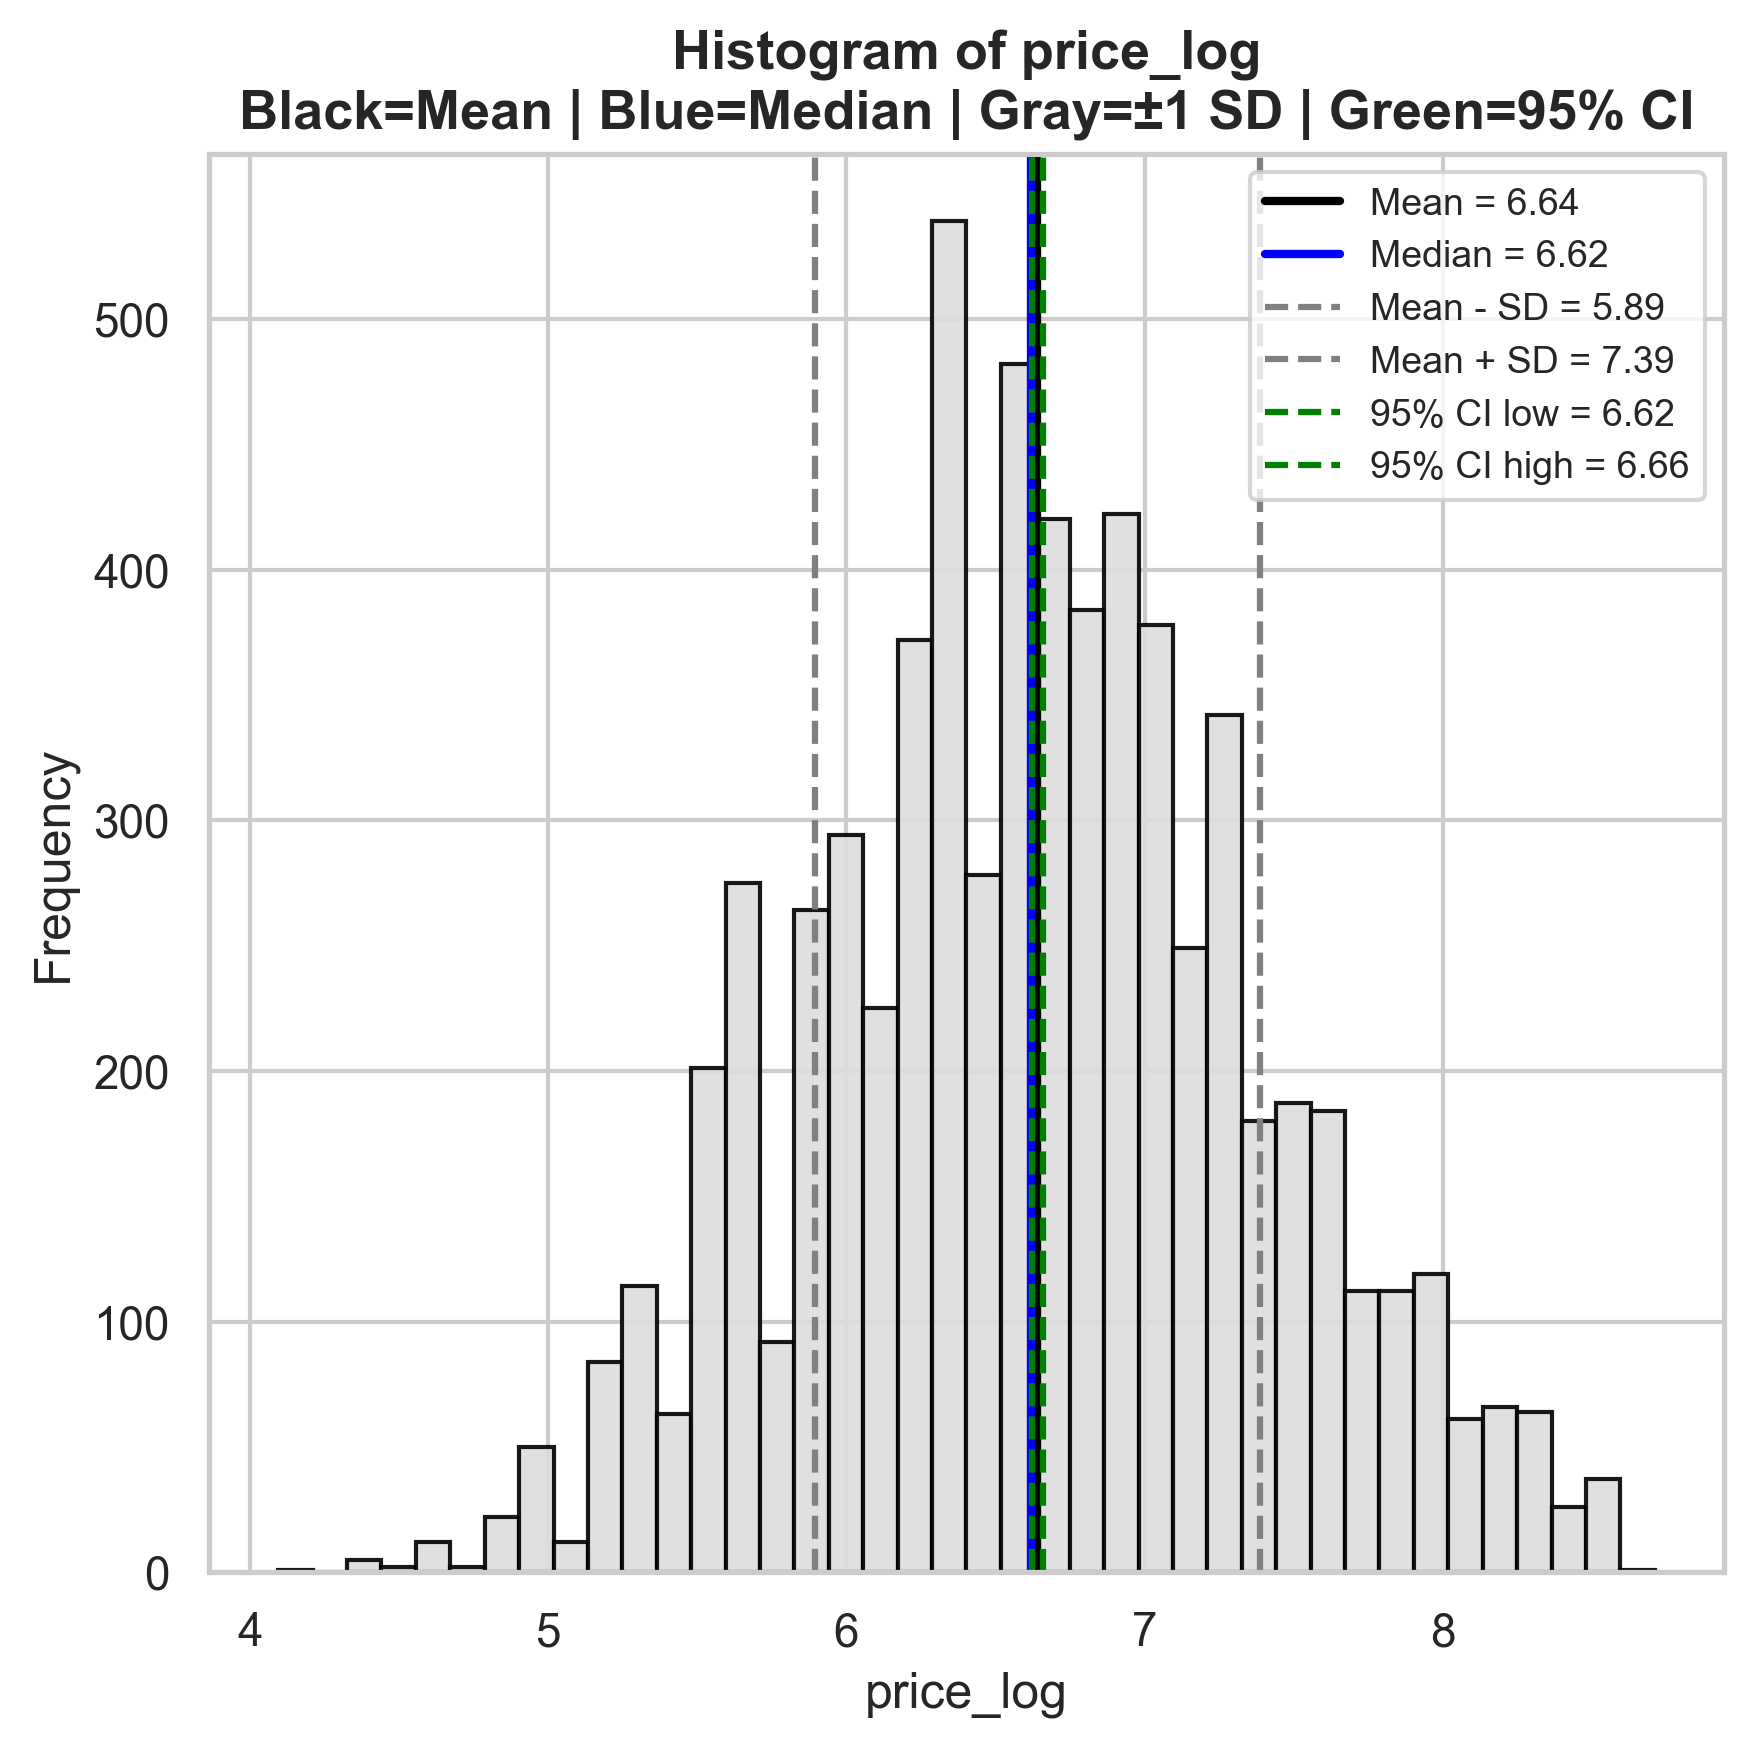

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price_log,6733,6.640848,6.620073,0.746829,6.623006,6.65869,6.131226,7.130899,0.999672,4.631718,8.630407,21,0.050709,Approximately symmetric.



Unique values table
Number of non-nulls: 6733
Number of unique values: 383


,column,value,count,frequency_non_null
0,price_log,4.0943445622221,1,0.000149
1,price_log,4.382026634673881,5,0.000743
2,price_log,4.499809670330265,2,0.000297
3,price_log,4.605170185988092,12,0.001782
4,price_log,4.700480365792417,2,0.000297
...,...,...,...,...
378,price_log,8.496990484098719,3,0.000446
379,price_log,8.515191188745565,3,0.000446
380,price_log,8.517193191416238,29,0.004307
381,price_log,8.525756422076725,1,0.000149



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price_log,numeric,apartment_id,numeric,Pearson,0.004140,7.341026e-01,Not significant,Not statistically significant at p < 0.05.,
1,price_log,numeric,name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price_log,numeric,description,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
3,price_log,numeric,host_id,numeric,Pearson,-0.012719,2.967014e-01,Not significant,Not statistically significant at p < 0.05.,
4,price_log,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
5,price_log,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
6,price_log,numeric,room_type,categorical,Chi-square,3282.700920,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,price_log,numeric,accommodates,numeric,Pearson,0.653591,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,price_log,numeric,bathrooms,numeric,Pearson,0.433029,6.864140e-306,Significant,Statistically significant at p < 0.05.,
9,price_log,numeric,bedrooms,numeric,Pearson,0.433029,6.864140e-306,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.050709,Approximately symmetric.,Baseline.
1,Log Transformation,-0.259786,Approximately symmetric.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.102259,Approximately symmetric.,Little change in skewness.
3,Box-Cox Transformation,-0.006456,Approximately symmetric.,Little change in skewness. Improved using lamb...


In [21]:
analysis = analyze_single_field(alojamentos_df, 
                                target_col="price_log", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

In [22]:
alojamentos_df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'price_log'],
      dtype='object')

In [ ]:
sns.pairplot(alojamentos_df[['price_log', 'city', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       ]], diag_kind ='kde')

# sns.pairplot(users_profiles[["Age group", "KPI_260_avg_spending", "KPI_over_mean_total_spending", "# transactions", "Avg_time_between_transactions_days", "Median_time_between_transactions_days", "Min_time_between_transactions_days", "Max_time_between_transactions_days", "Avg_nr_transactions_per_year", "Recency_score", "Year_frequency_score", "Loyalty_category", "Avg_customer_value_per_year", "CLV_3y", "Main_channel"]], hue='Recency_score', diag_kind = 'kde')
plt.show()

In [ ]:
sns.pairplot(alojamentos_df[['price_log', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'city']], diag_kind ='kde')

In [ ]:
scatt = px.scatter(users_profiles, x = 'Total spending', y = '# of acquisitions')
scatt.update_layout(
    title_text = "Distribution of total spendings ($) and number of buys performed by users",
    xaxis_title_text = "Total Spending, $",
    yaxis_title_text = "Number of acquisitions",
    width=500,
    height=500,
    autosize=False
)

In [ ]:
vio = px.violin(users_profiles, x="country", y="Avg spending", 
                title="Users' spending in different countries",
                box=True, points="all", violinmode='overlay')
vio.update_layout(xaxis_title = "Countries",
                  yaxis_title = "Average spending, $",
                  width = 1000,
                  height=500)
vio.show()

In [25]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal

try:
    from IPython.display import display
except ImportError:
    display = print


def price_analysis_report(
    alojamentos_df,
    price_col='price_log',
    raw_price_col='price',
    split_cols=('room_type', 'city'),
    output_dir='outputs',
    max_numeric_plots=None,
    max_categorical_plots=None,
    min_group_size=5,
    dpi=140
):
    """
    Build descriptive statistics, association tables, and plots for price_log
    split by room_type and city.

    Parameters
    ----------
    alojamentos_df : pd.DataFrame
    price_col : str, default 'price_log'
        Log-transformed price column.
    raw_price_col : str, default 'price'
        Original price column.
    split_cols : tuple, default ('room_type', 'city')
        Grouping columns.
    output_dir : str, default 'outputs'
        Folder to save csv tables and png plots.
    max_numeric_plots : int or None
        Limit number of numeric plots if there are too many.
    max_categorical_plots : int or None
        Limit number of categorical plots if there are too many.
    min_group_size : int, default 5
        Minimum rows per level for Kruskal/violin plots.
    dpi : int, default 140

    Returns
    -------
    dict with tables
    """

    df = alojamentos_df.copy()
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    required_cols = [price_col, raw_price_col] + list(split_cols)
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df[raw_price_col] = pd.to_numeric(df[raw_price_col], errors='coerce')

    def sanitize_filename(text):
        text = str(text)
        for ch in ['/', '\\', ':', '*', '?', '"', '<', '>', '|', ' ']:
            text = text.replace(ch, '_')
        return text[:180]

    def ci95(series):
        s = pd.to_numeric(series, errors='coerce').dropna()
        n = len(s)
        if n == 0:
            return (np.nan, np.nan)
        if n == 1:
            return (s.mean(), s.mean())
        mean = s.mean()
        sem = stats.sem(s, nan_policy='omit')
        low, high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
        return low, high

    def summarize(series):
        s = pd.to_numeric(series, errors='coerce').dropna()
        if len(s) == 0:
            return {
                'n': 0,
                'mean': np.nan,
                'ci95_low': np.nan,
                'ci95_high': np.nan,
                'sd': np.nan,
                'median': np.nan,
                'q1': np.nan,
                'q3': np.nan,
                'iqr': np.nan,
                'min': np.nan,
                'max': np.nan
            }

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        low, high = ci95(s)

        return {
            'n': len(s),
            'mean': s.mean(),
            'ci95_low': low,
            'ci95_high': high,
            'sd': s.std(ddof=1),
            'median': s.median(),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1,
            'min': s.min(),
            'max': s.max()
        }

    # --------------------------------------------------
    # 1. Summary table by room_type and city
    # --------------------------------------------------
    summary_rows = []

    for keys, g in df.groupby(list(split_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {col: val for col, val in zip(split_cols, keys)}

        log_stats = summarize(g[price_col])
        raw_stats = summarize(g[raw_price_col])

        row.update({f'{price_col}_{k}': v for k, v in log_stats.items()})
        row.update({f'{raw_price_col}_{k}': v for k, v in raw_stats.items()})

        summary_rows.append(row)

    stats_table = pd.DataFrame(summary_rows).sort_values(list(split_cols)).reset_index(drop=True)
    stats_table.to_csv(output_path / 'price_stats_by_room_type_city.csv', index=False)

    print("\nDescriptive statistics by room_type and city")
    display(stats_table)

    # --------------------------------------------------
    # 2. Association tests
    # --------------------------------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_features = [c for c in numeric_cols if c != price_col]
    categorical_features = [c for c in df.columns if c not in numeric_cols and c != price_col]

    if max_numeric_plots is not None:
        numeric_features = numeric_features[:max_numeric_plots]
    if max_categorical_plots is not None:
        categorical_features = categorical_features[:max_categorical_plots]

    pearson_results = []
    spearman_results = []
    kruskal_results = []

    # Pearson for numeric
    for feature in numeric_features:
        tmp = df[[price_col, feature]].dropna()
        if len(tmp) >= 3 and tmp[feature].nunique() > 1 and tmp[price_col].nunique() > 1:
            try:
                r, p = pearsonr(tmp[price_col], tmp[feature])
            except Exception:
                r, p = np.nan, np.nan

            pearson_results.append({
                'target': price_col,
                'feature': feature,
                'n': len(tmp),
                'pearson_r': r,
                'p_value': p
            })

    pearson_df = pd.DataFrame(pearson_results).sort_values('p_value', na_position='last')
    pearson_df.to_csv(output_path / 'price_log_numeric_pearson.csv', index=False)

    print("\nPearson correlations with numeric features")
    display(pearson_df)

    # Spearman + Kruskal for categorical
    for feature in categorical_features:
        tmp = df[[price_col, feature]].dropna()
        if len(tmp) == 0:
            continue

        # Spearman using category codes
        try:
            codes = tmp[feature].astype('category').cat.codes
            if codes.nunique() > 1 and tmp[price_col].nunique() > 1:
                rho, p = spearmanr(tmp[price_col], codes)
                spearman_results.append({
                    'target': price_col,
                    'feature': feature,
                    'n': len(tmp),
                    'spearman_rho': rho,
                    'p_value': p
                })
        except Exception:
            pass

        # Kruskal-Wallis across categories
        groups = []
        for _, sub in tmp.groupby(feature):
            vals = sub[price_col].dropna()
            if len(vals) >= min_group_size:
                groups.append(vals.values)

        if len(groups) >= 2:
            try:
                h, pkw = kruskal(*groups)
            except Exception:
                h, pkw = np.nan, np.nan

            kruskal_results.append({
                'target': price_col,
                'feature': feature,
                'groups_tested': len(groups),
                'n_total': int(sum(len(g) for g in groups)),
                'kruskal_h': h,
                'p_value': pkw
            })

    spearman_df = pd.DataFrame(spearman_results).sort_values('p_value', na_position='last')
    kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value', na_position='last')

    spearman_df.to_csv(output_path / 'price_log_categorical_spearman.csv', index=False)
    kruskal_df.to_csv(output_path / 'price_log_categorical_kruskal.csv', index=False)

    print("\nSpearman correlations with categorical features")
    display(spearman_df)

    print("\nKruskal-Wallis tests for categorical features")
    display(kruskal_df)

    # --------------------------------------------------
    # 3. Plots
    # --------------------------------------------------
    sns.set_theme(style='whitegrid')

    # Numeric plots: scatterplot + jointplot
    for feature in numeric_features:
        if feature == raw_price_col:
            continue

        tmp = df[[price_col, feature]].dropna()
        if len(tmp) < 3 or tmp[feature].nunique() <= 1:
            continue

        # Scatterplot
        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=tmp, x=feature, y=price_col, alpha=0.55, s=35)
        sns.regplot(data=tmp, x=feature, y=price_col, scatter=False, color='crimson')
        plt.title(f'{price_col} vs {feature} - scatterplot')
        plt.tight_layout()
        scatter_file = output_path / f'scatter_{sanitize_filename(feature)}.png'
        plt.savefig(scatter_file, dpi=dpi, bbox_inches='tight')
        plt.show()

        # Jointplot
        jp = sns.jointplot(data=tmp, x=feature, y=price_col, kind='scatter', height=6, alpha=0.5)
        jp.fig.suptitle(f'{price_col} vs {feature} - jointplot', y=1.02)
        joint_file = output_path / f'jointplot_{sanitize_filename(feature)}.png'
        jp.fig.savefig(joint_file, dpi=dpi, bbox_inches='tight')
        plt.show()

    # Categorical plots: violinplot
    for feature in categorical_features:
        tmp = df[[price_col, feature]].dropna().copy()
        if tmp.empty or tmp[feature].nunique() < 2:
            continue

        # keep only levels with enough data
        counts = tmp[feature].value_counts()
        keep = counts[counts >= min_group_size].index
        tmp = tmp[tmp[feature].isin(keep)]

        if tmp.empty or tmp[feature].nunique() < 2:
            continue

        order = (
            tmp.groupby(feature)[price_col]
            .median()
            .sort_values()
            .index
        )

        plt.figure(figsize=(10, 5))
        sns.violinplot(data=tmp, x=feature, y=price_col, order=order, inner='box', cut=0)
        plt.title(f'{price_col} by {feature} - violinplot')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        violin_file = output_path / f'violin_{sanitize_filename(feature)}.png'
        plt.savefig(violin_file, dpi=dpi, bbox_inches='tight')
        plt.show()

    print(f"\nAll tables and figures were saved to: {output_path.resolve()}")

    return {
        'stats_table': stats_table,
        'pearson_table': pearson_df,
        'spearman_table': spearman_df,
        'kruskal_table': kruskal_df
    }


Descriptive statistics by room_type and city


,room_type,city,price_log_n,price_log_mean,price_log_ci95_low,price_log_ci95_high,price_log_sd,price_log_median,price_log_q1,price_log_q3,...,price_mean,price_ci95_low,price_ci95_high,price_sd,price_median,price_q1,price_q3,price_iqr,price_min,price_max
0,Entire home/apt,barcelona,950,6.993037,6.956774,7.029300,0.569535,6.907755,6.620073,7.313220,...,1293.357895,1238.465238,1348.250552,862.131911,1000.0,750.0,1500.0,750.0,240.0,5000.0
1,Entire home/apt,girona,1029,6.927137,6.891466,6.962809,0.583129,6.856462,6.507278,7.279319,...,1222.176871,1171.071467,1273.282275,835.439098,950.0,670.0,1450.0,780.0,100.0,5000.0
2,Entire home/apt,madrid,901,6.712256,6.680709,6.743803,0.482490,6.672033,6.396930,6.956545,...,938.102109,899.162835,977.041382,595.549284,790.0,600.0,1050.0,450.0,190.0,5000.0
3,Entire home/apt,malaga,278,6.558968,6.499845,6.618091,0.500759,6.476972,6.214608,6.810682,...,815.000000,749.592742,880.407258,553.985722,650.0,500.0,907.5,407.5,200.0,5000.0
4,Entire home/apt,mallorca,1006,7.282774,7.248293,7.317255,0.557320,7.279319,6.907755,7.657989,...,1693.767396,1633.958112,1753.576679,966.709875,1450.0,1000.0,2117.5,1117.5,100.0,5000.0
5,Entire home/apt,menorca,128,7.229103,7.121425,7.336780,0.615637,7.268920,6.802395,7.697346,...,1649.609375,1477.434925,1821.783825,984.390696,1435.0,900.0,2202.5,1302.5,330.0,4900.0
6,Entire home/apt,sevilla,262,6.756953,6.688647,6.825259,0.561489,6.672033,6.309918,7.090077,...,1032.671756,937.720317,1127.623195,780.522788,790.0,550.0,1200.0,650.0,340.0,5000.0
7,Entire home/apt,valencia,226,6.548640,6.488561,6.608719,0.458339,6.529419,6.296156,6.762679,...,793.601770,717.569291,869.634248,580.046696,685.0,542.5,865.0,322.5,240.0,6071.0
8,Hotel room,barcelona,7,7.199386,6.765963,7.632809,0.468643,7.313220,7.155774,7.477712,...,1444.285714,982.268188,1906.303240,499.561713,1500.0,1285.0,1770.0,485.0,500.0,2000.0
9,Hotel room,girona,4,6.119395,4.420434,7.818357,1.067708,6.403826,5.812249,6.710973,...,625.000000,-86.201396,1336.201396,446.952645,615.0,400.0,840.0,440.0,100.0,1170.0



Pearson correlations with numeric features


,target,feature,n,pearson_r,p_value
0,price_log,accommodates,6733,0.653591,0.000000e+00
3,price_log,beds,6733,0.569973,0.000000e+00
4,price_log,price,6733,0.894781,0.000000e+00
1,price_log,bathrooms,6733,0.433029,6.864140e-306
2,price_log,bedrooms,6733,0.433029,6.864140e-306
19,price_log,reviews_per_month,5530,-0.203595,7.979158e-53
11,price_log,number_of_reviews,6733,-0.159695,1.055806e-39
10,price_log,availability_365,6733,0.157255,1.548375e-38
7,price_log,availability_30,6733,0.120853,2.491659e-23
8,price_log,availability_60,6733,0.101910,5.182876e-17



Spearman correlations with categorical features


,target,feature,n,spearman_rho,p_value
4,price_log,room_type,6733,-0.627980,0.000000e+00
9,price_log,city,6733,0.164356,5.550038e-42
2,price_log,neighbourhood_name,6733,-0.112769,1.676346e-20
8,price_log,is_instant_bookable,6733,0.079059,8.242282e-11
10,price_log,insert_date,6733,0.078480,1.130061e-10
3,price_log,neighbourhood_district,4075,-0.091193,5.485477e-09
5,price_log,has_availability,6733,0.049388,5.029477e-05
6,price_log,first_review_date,5530,0.044361,9.677556e-04
7,price_log,last_review_date,5530,0.044361,9.677556e-04
1,price_log,description,6706,0.022519,6.518707e-02



Kruskal-Wallis tests for categorical features


,target,feature,groups_tested,n_total,kruskal_h,p_value
2,price_log,room_type,4,6733,2684.292639,0.000000e+00
7,price_log,city,8,6733,1271.592605,2.320605e-270
0,price_log,neighbourhood_name,215,6209,1761.470685,4.481676e-241
8,price_log,insert_date,164,6733,1237.159110,2.059606e-164
1,price_log,neighbourhood_district,52,4054,407.110833,5.316114e-57
6,price_log,is_instant_bookable,2,6733,42.076816,8.775748e-11
3,price_log,has_availability,2,6733,16.420571,5.073168e-05
5,price_log,last_review_date,376,2861,477.974129,2.450111e-04
4,price_log,first_review_date,376,2861,477.974129,2.450111e-04


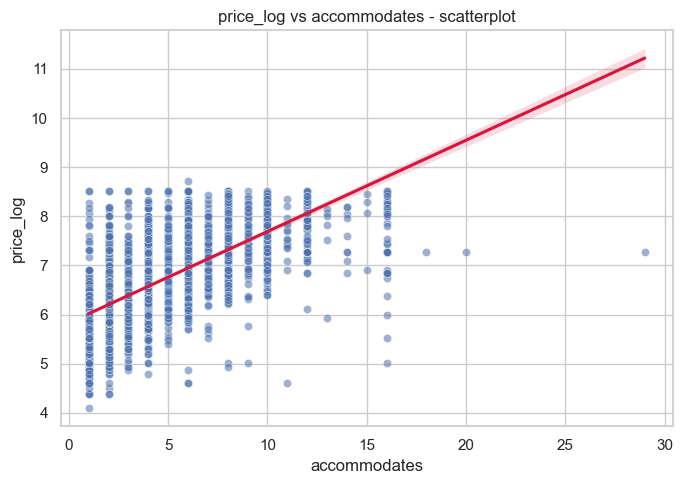

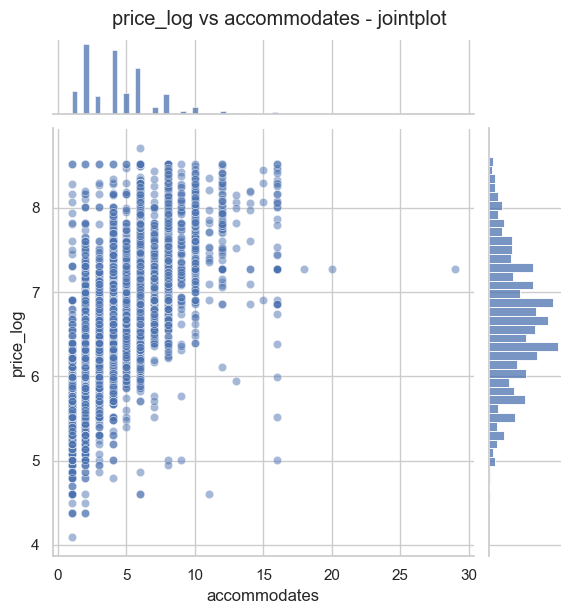

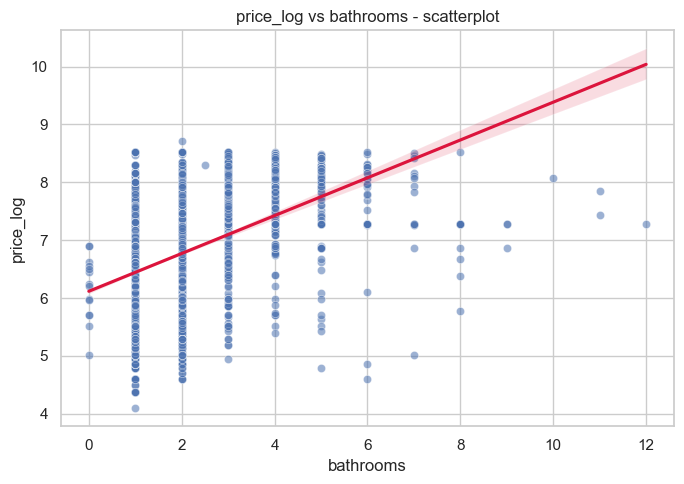

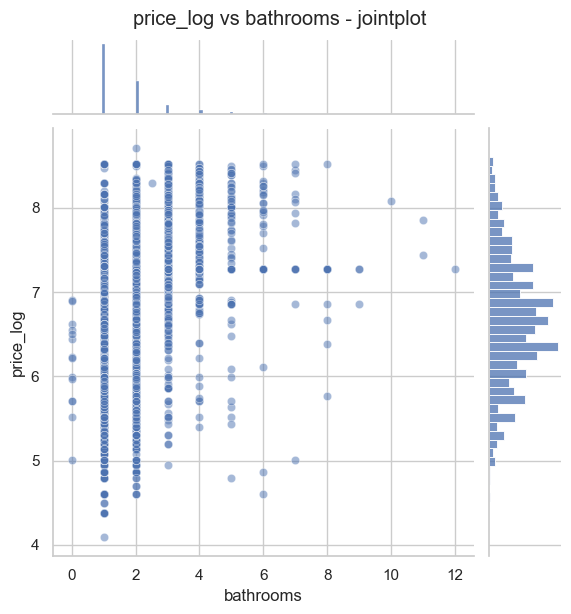

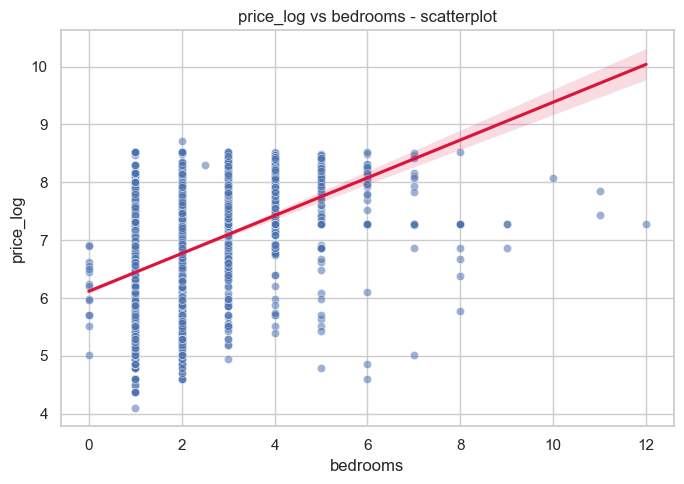

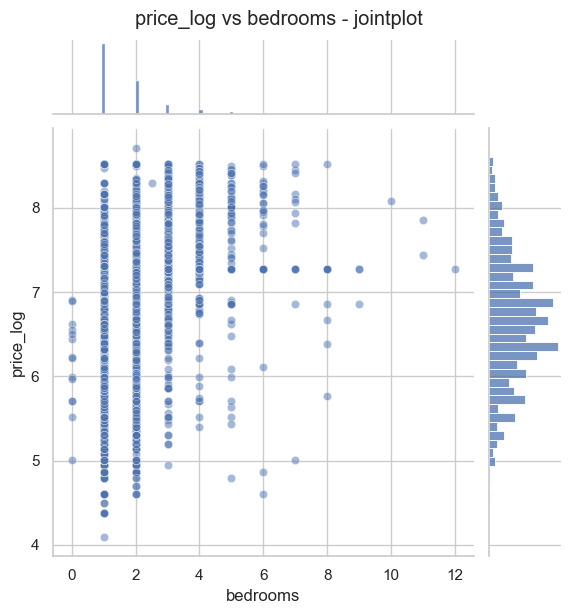

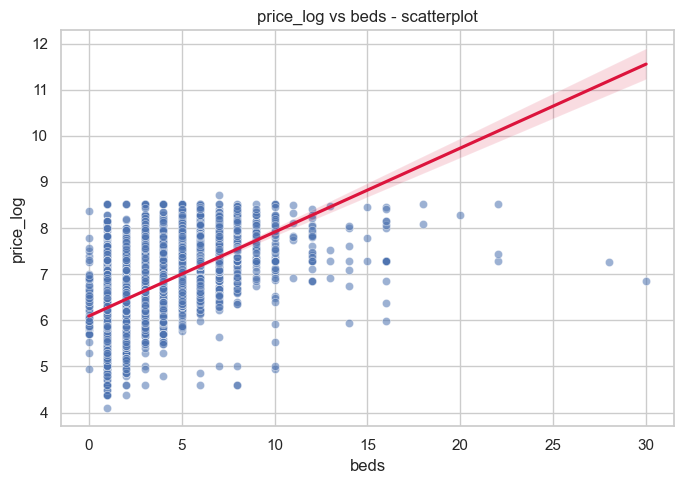

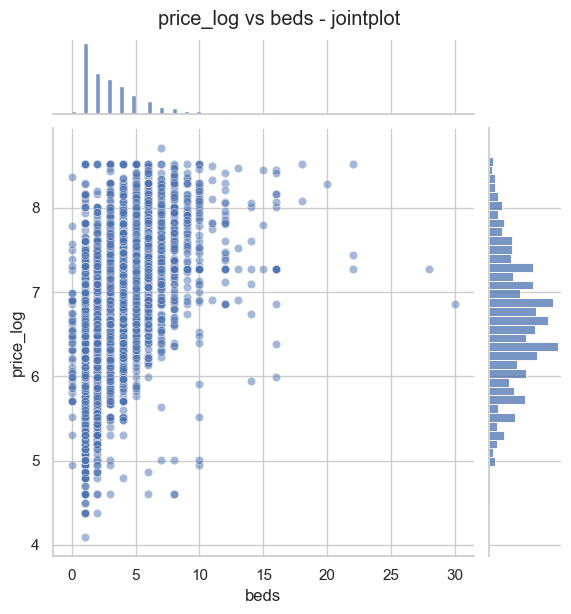

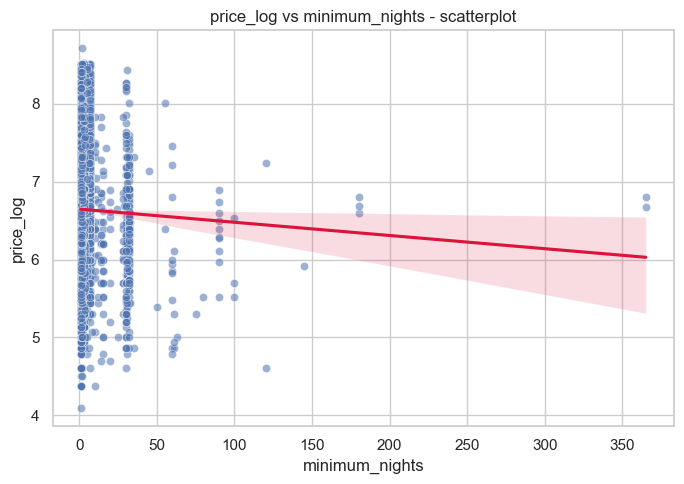

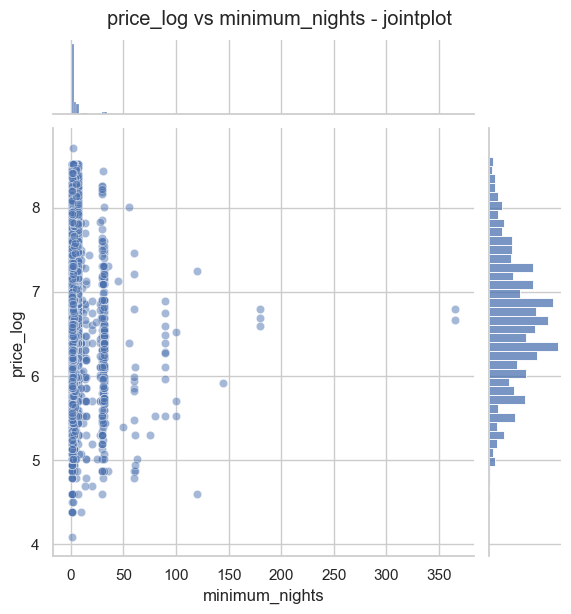

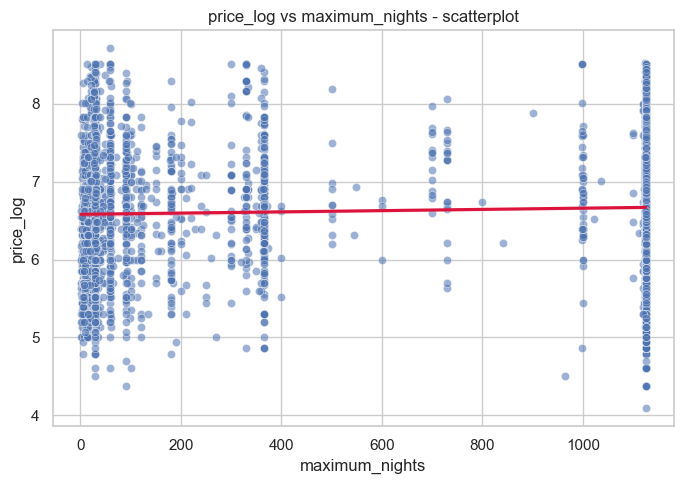

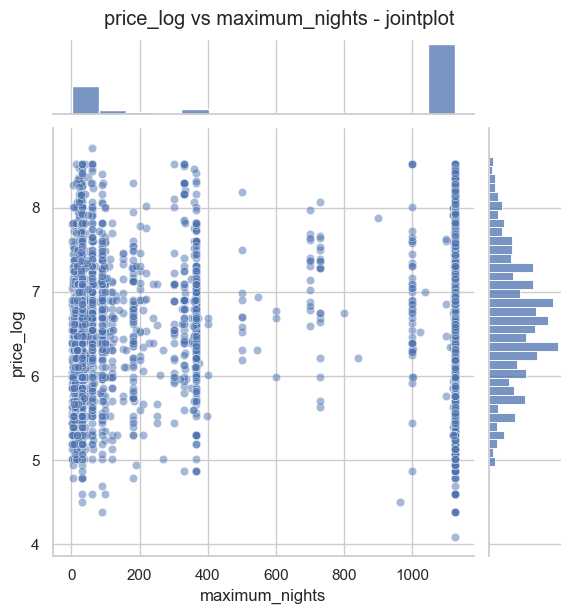

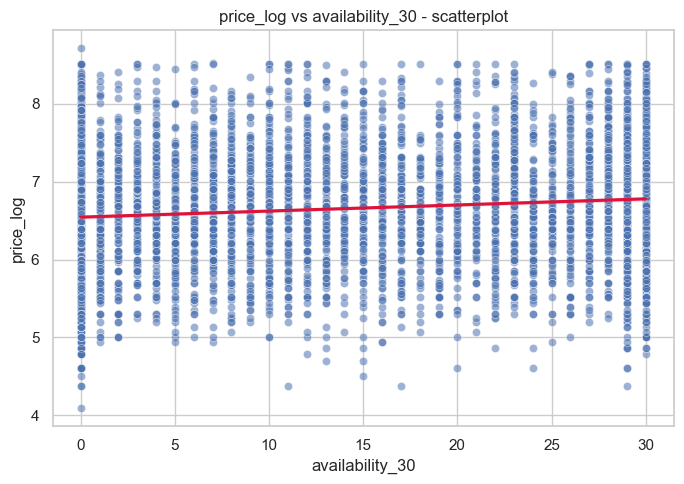

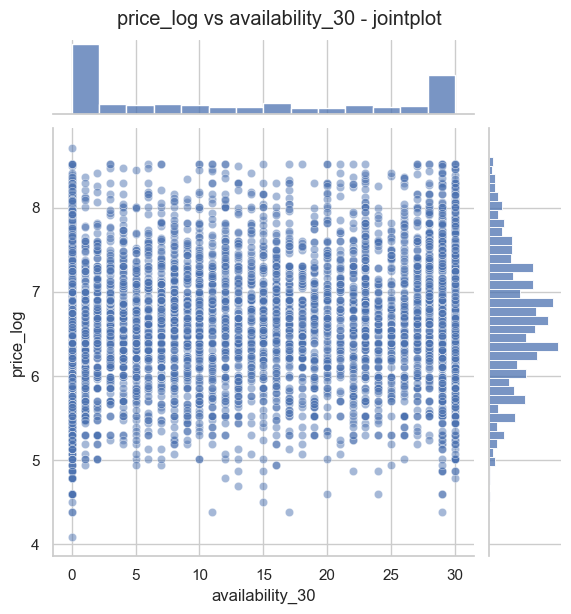

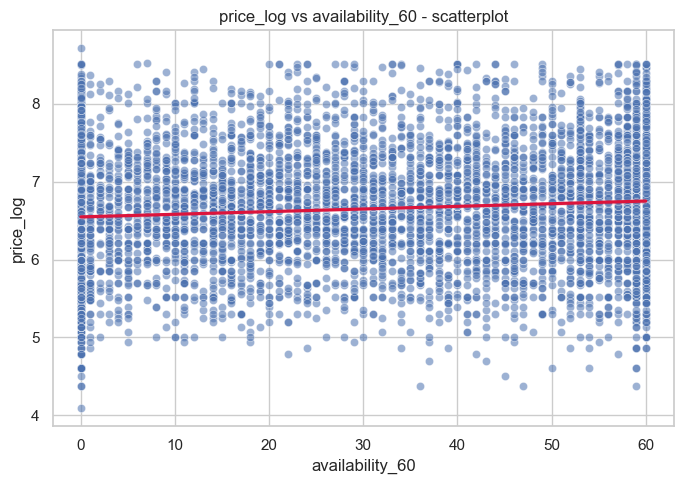

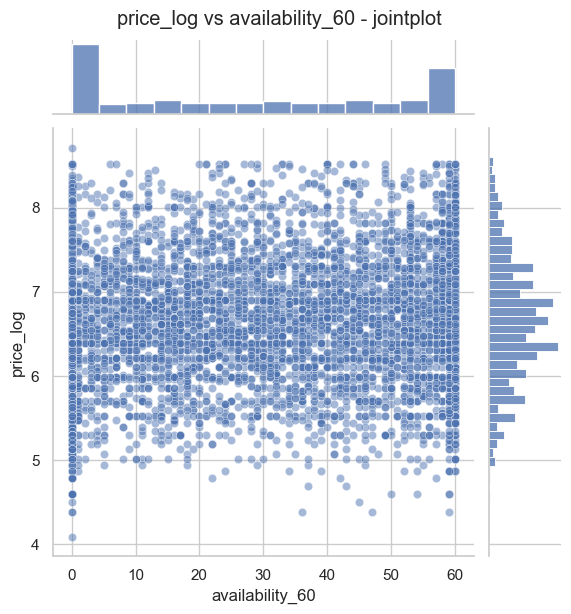

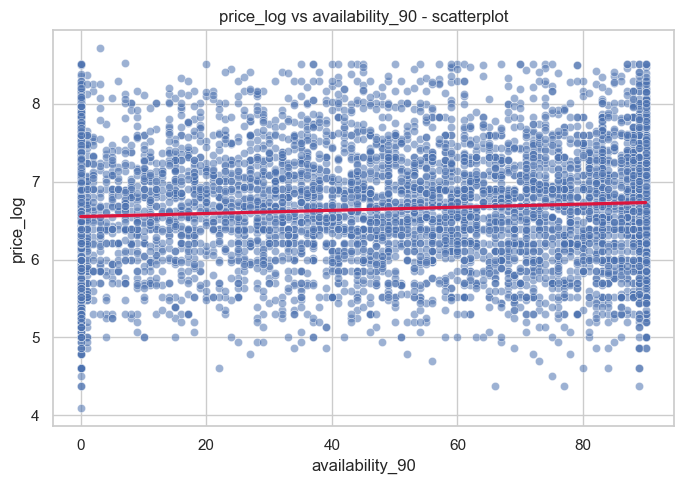

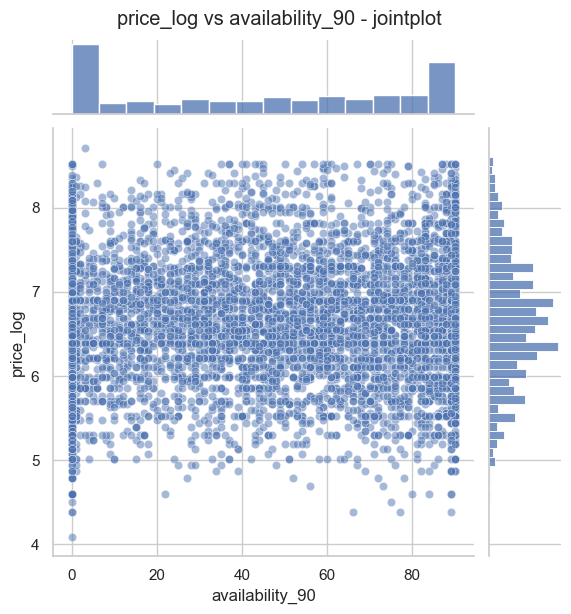

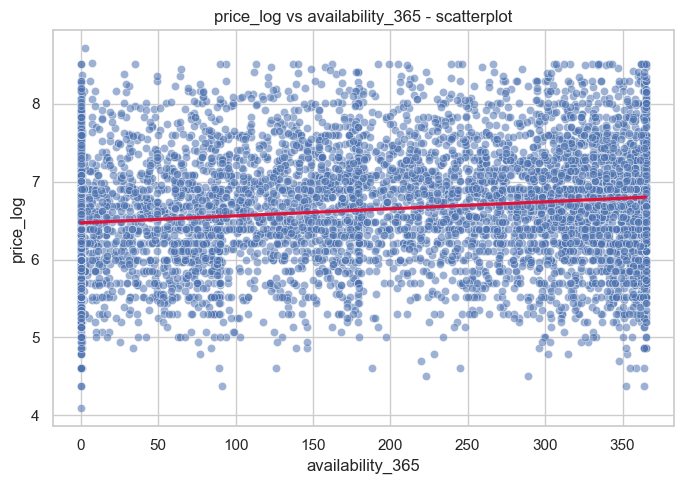

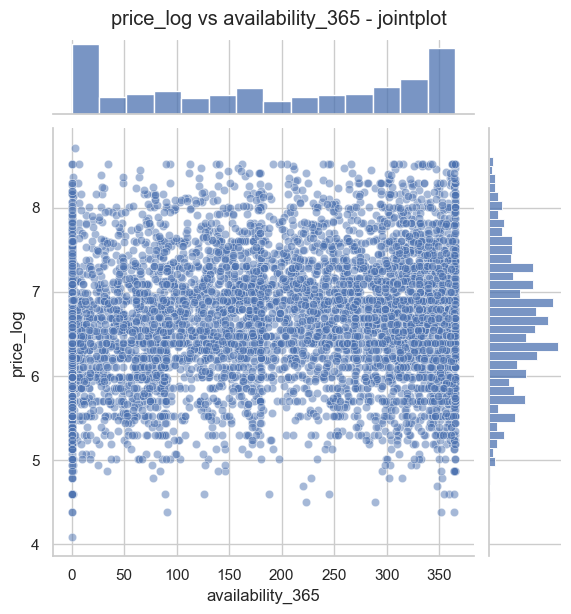

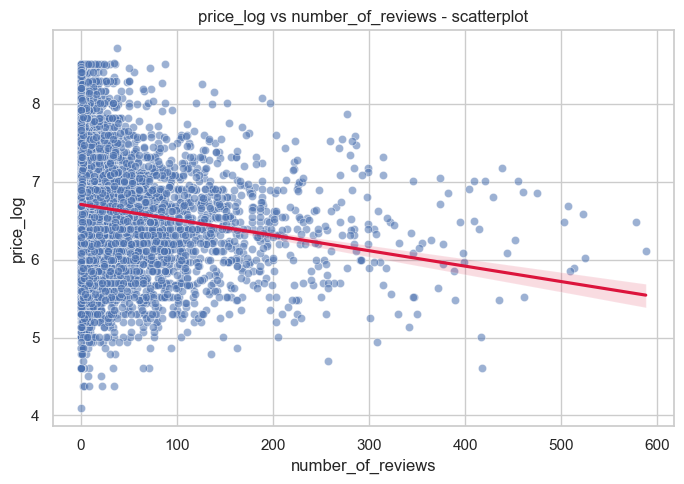

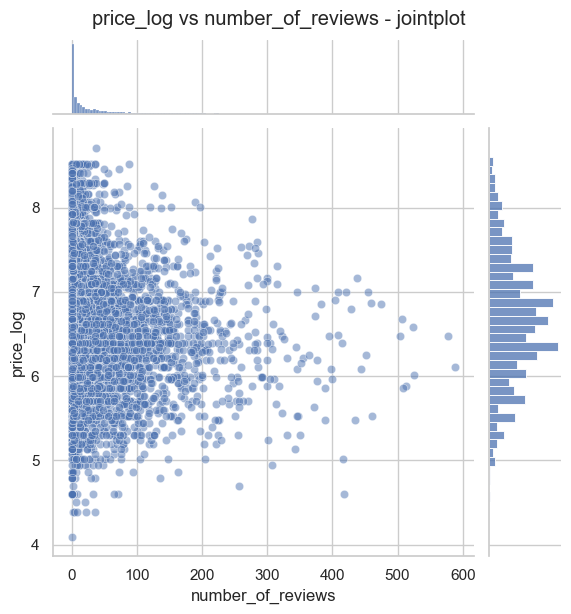

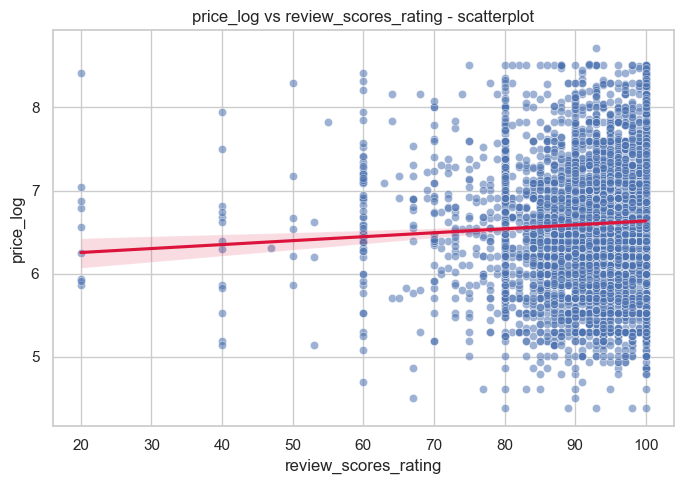

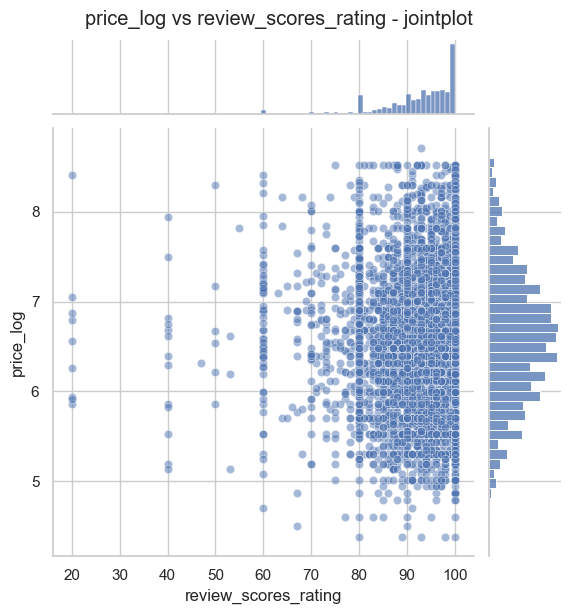

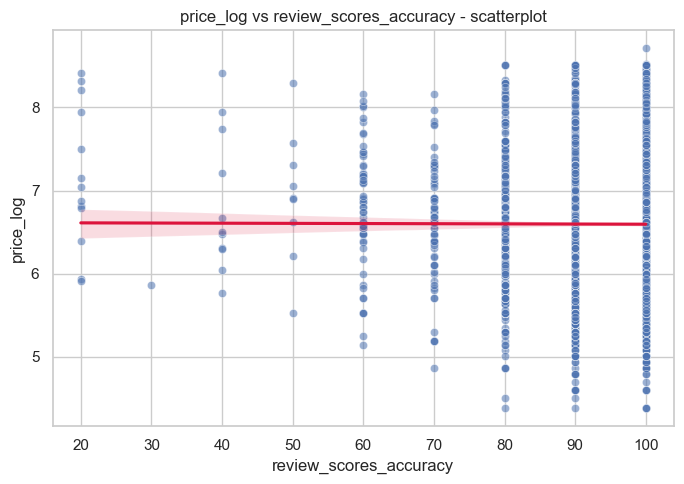

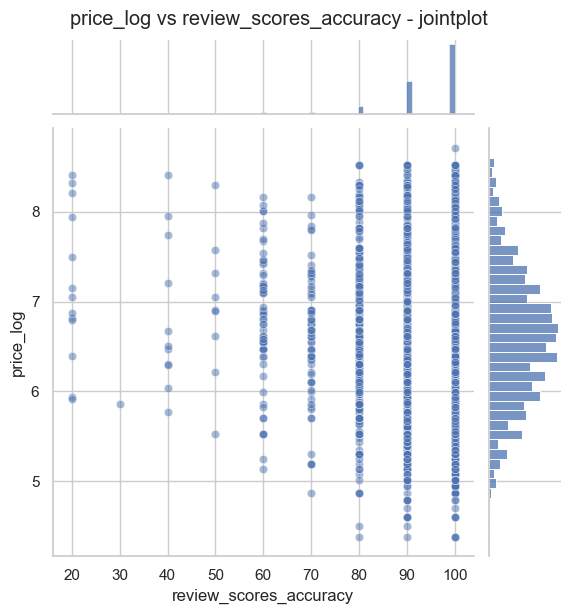

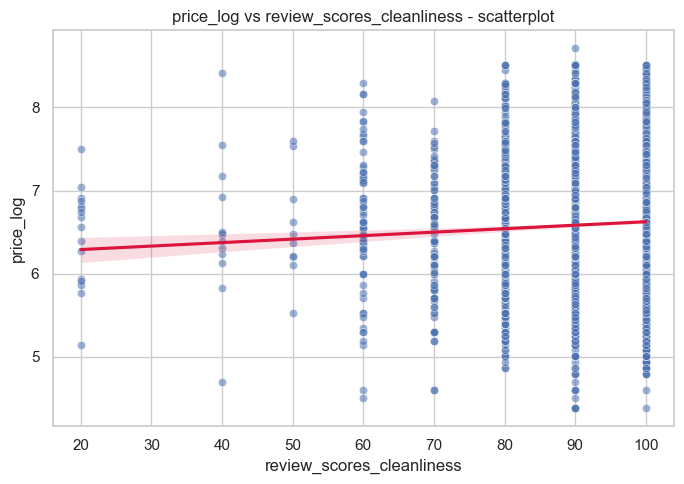

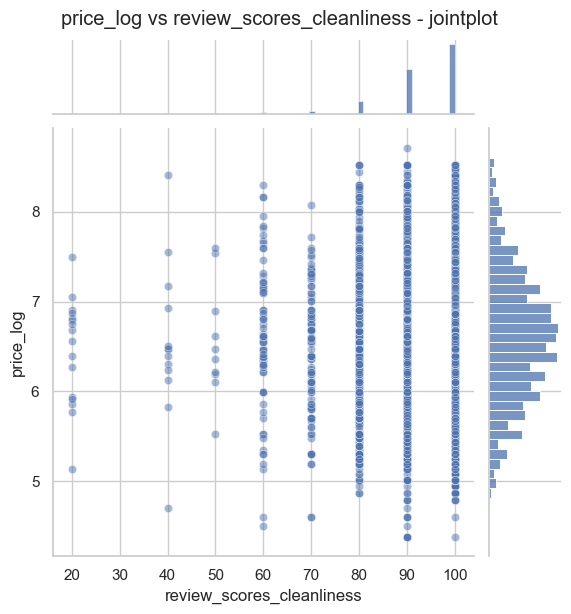

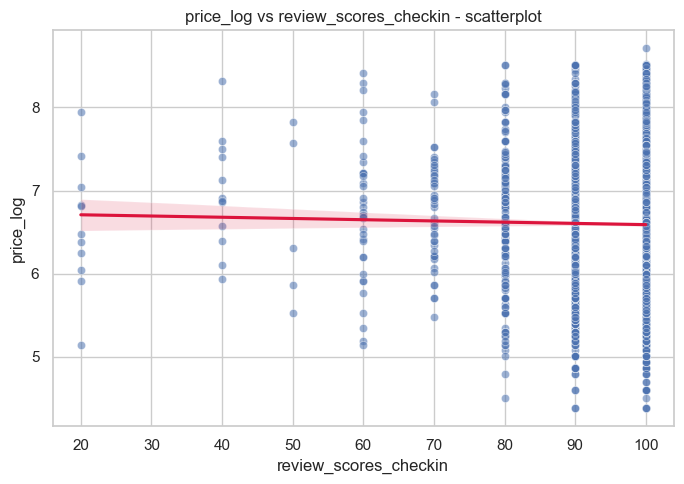

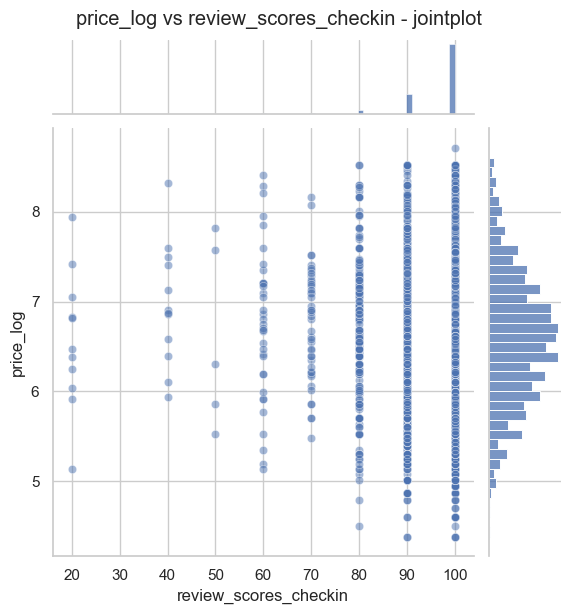

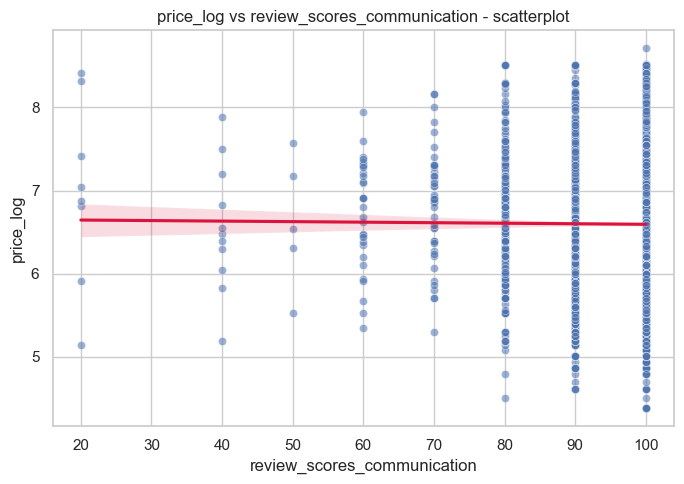

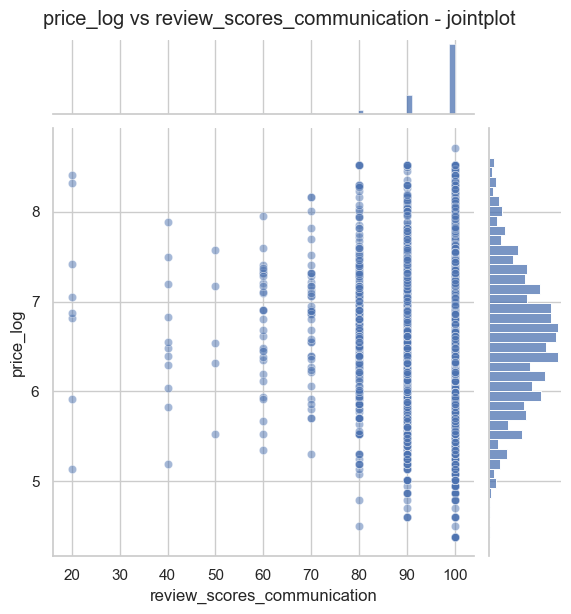

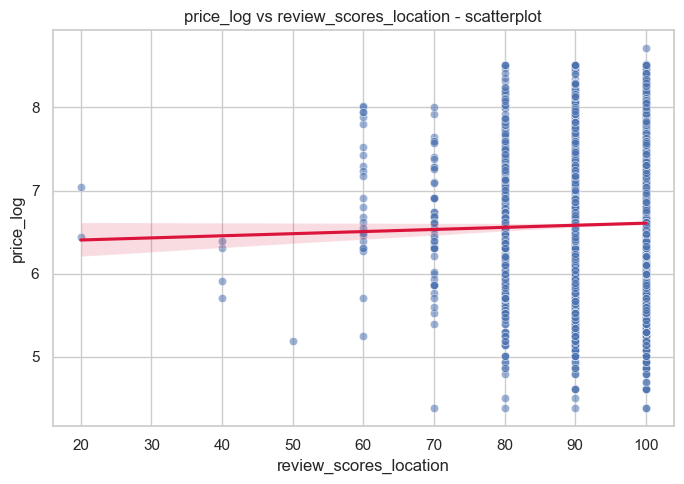

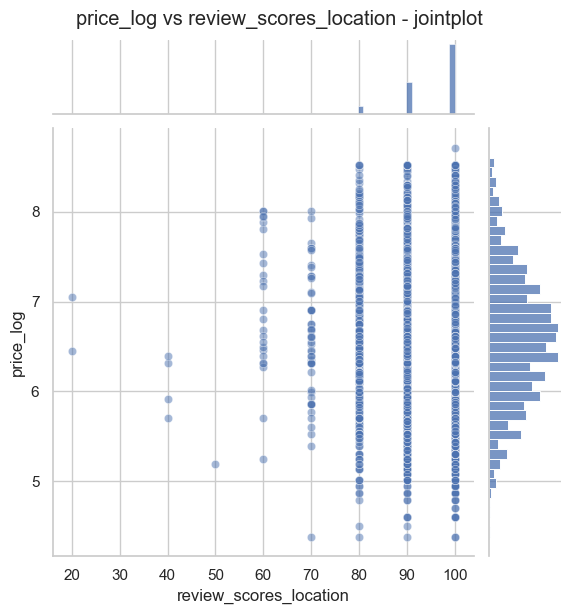

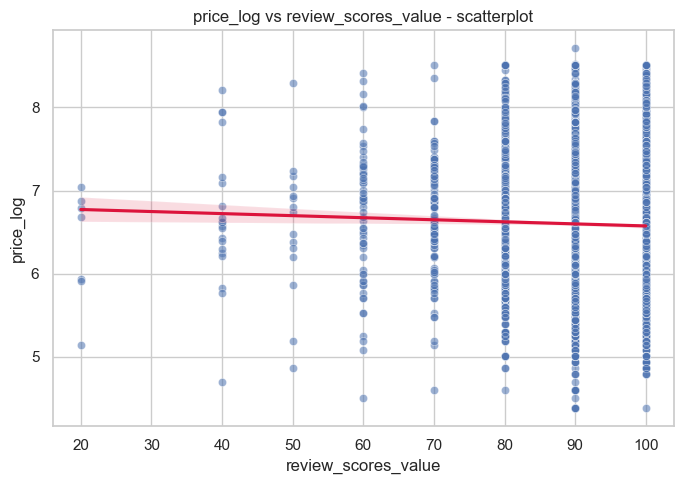

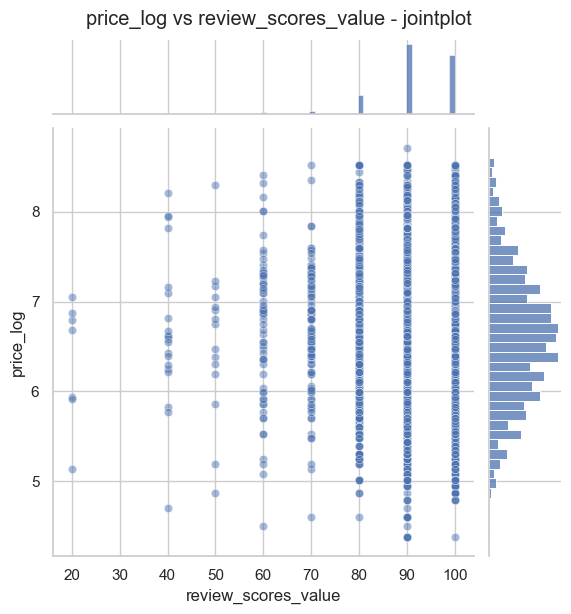

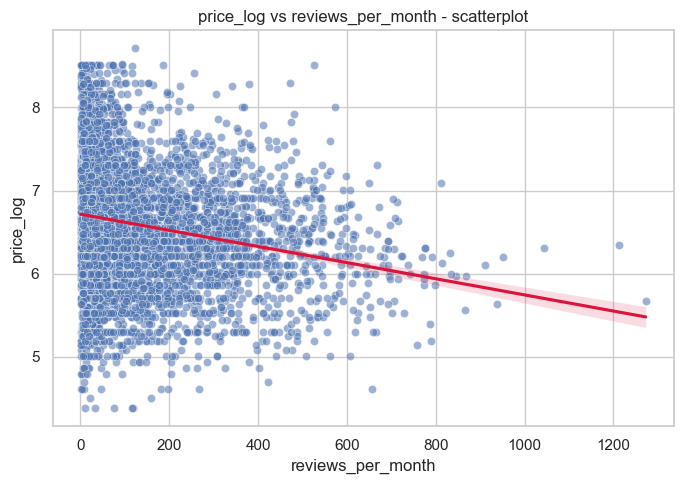

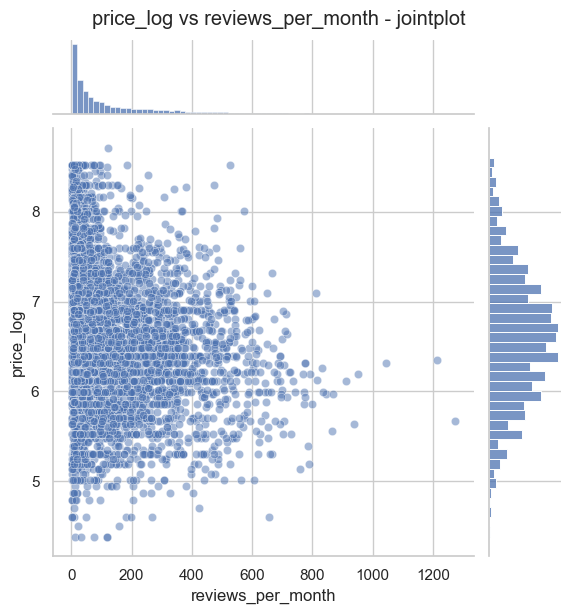

C:\Users\JobComp\AppData\Local\Temp\ipykernel_4504\109087287.py:298: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JobComp\AppData\Local\Temp\ipykernel_4504\109087287.py:300: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(violin_file, dpi=dpi, bbox_inches='tight')
C:\Users\JobComp\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


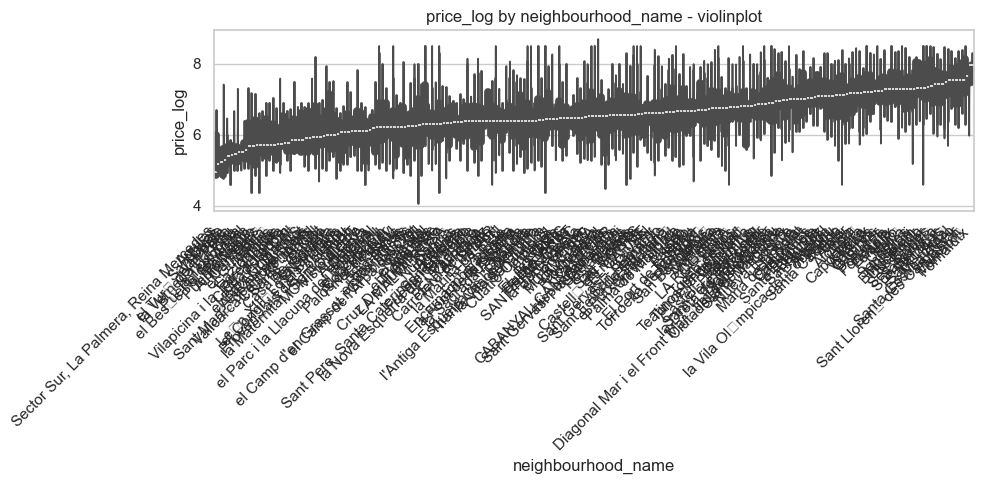

C:\Users\JobComp\AppData\Local\Temp\ipykernel_4504\109087287.py:298: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\JobComp\AppData\Local\Temp\ipykernel_4504\109087287.py:300: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(violin_file, dpi=dpi, bbox_inches='tight')
C:\Users\JobComp\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


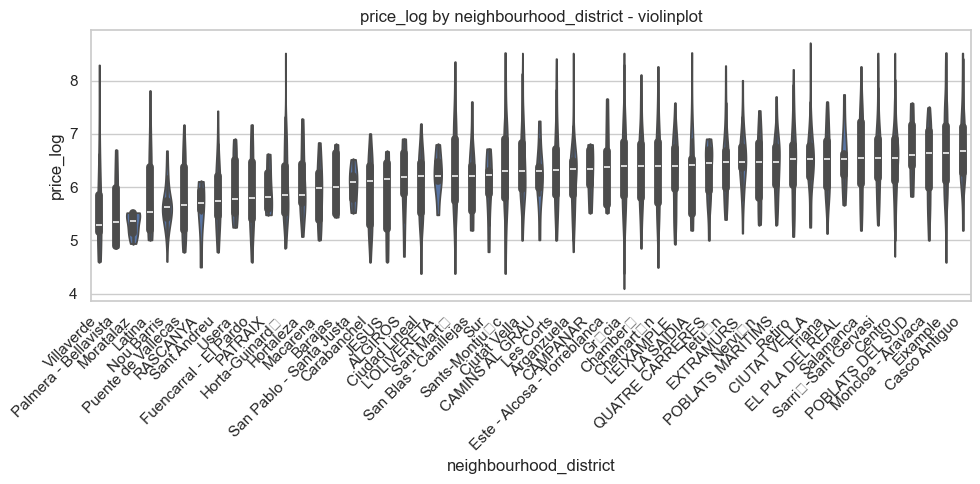

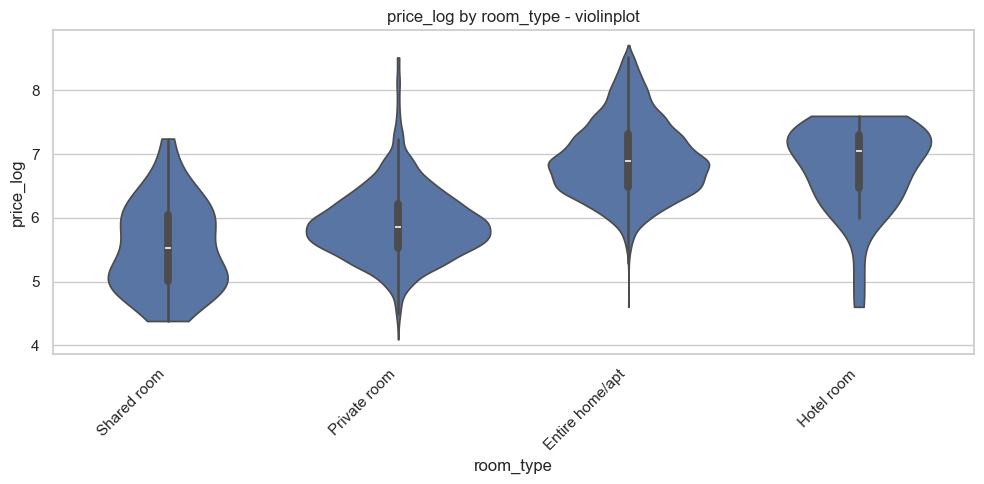

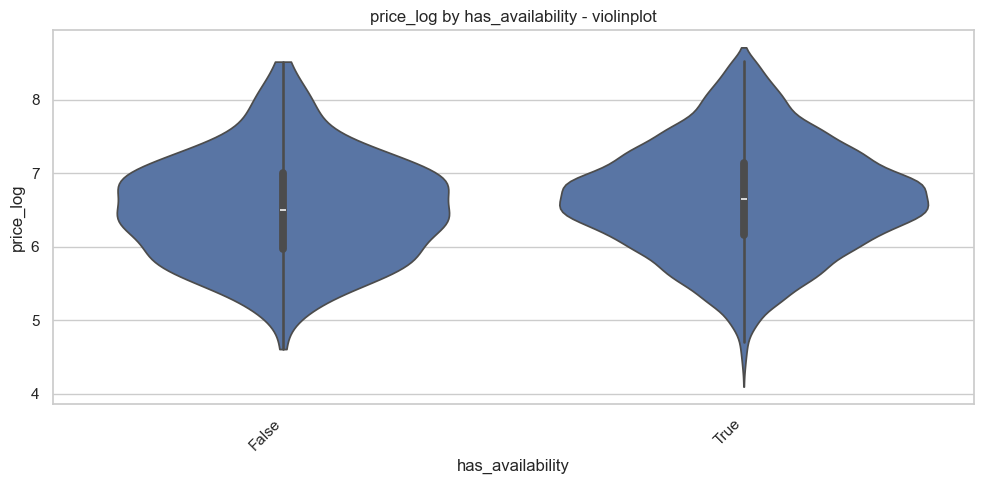

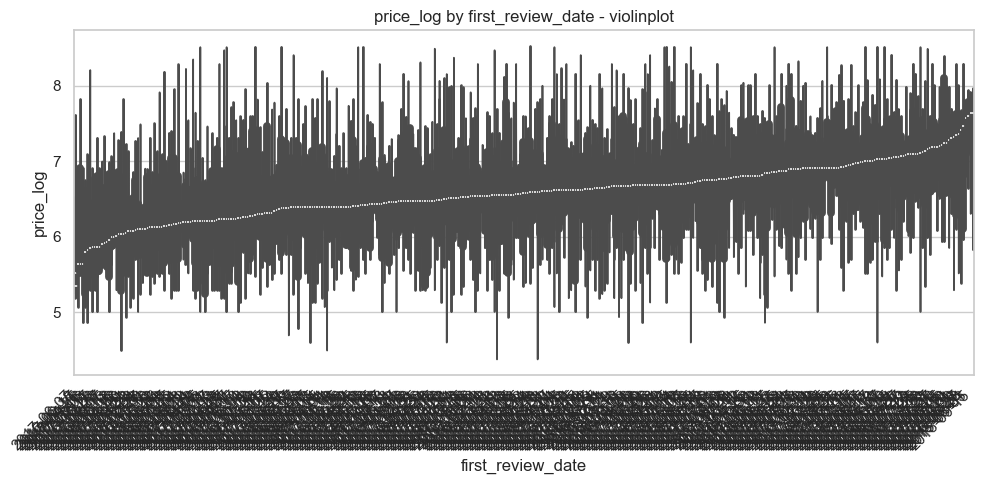

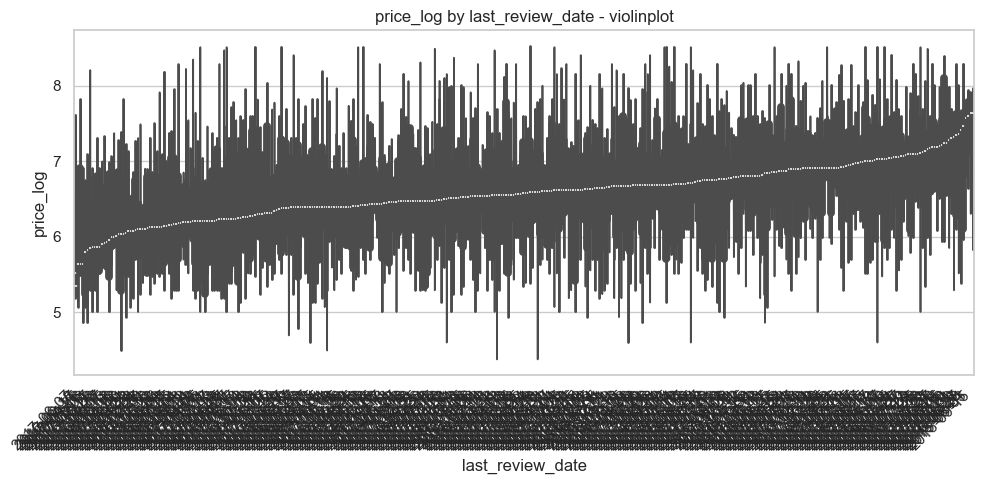

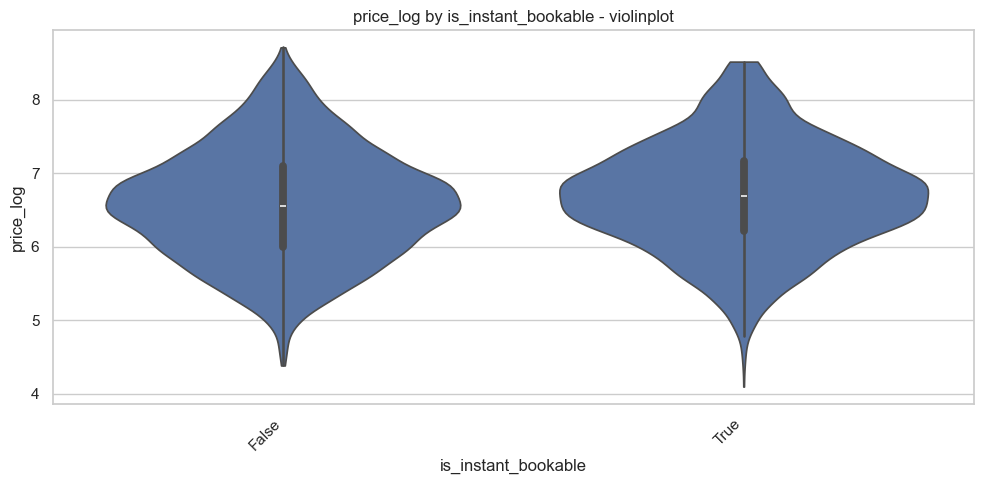

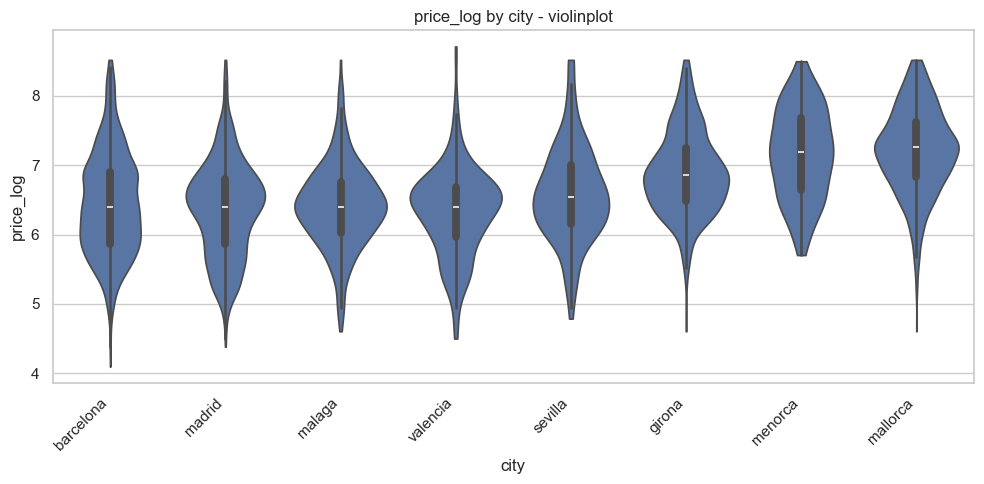

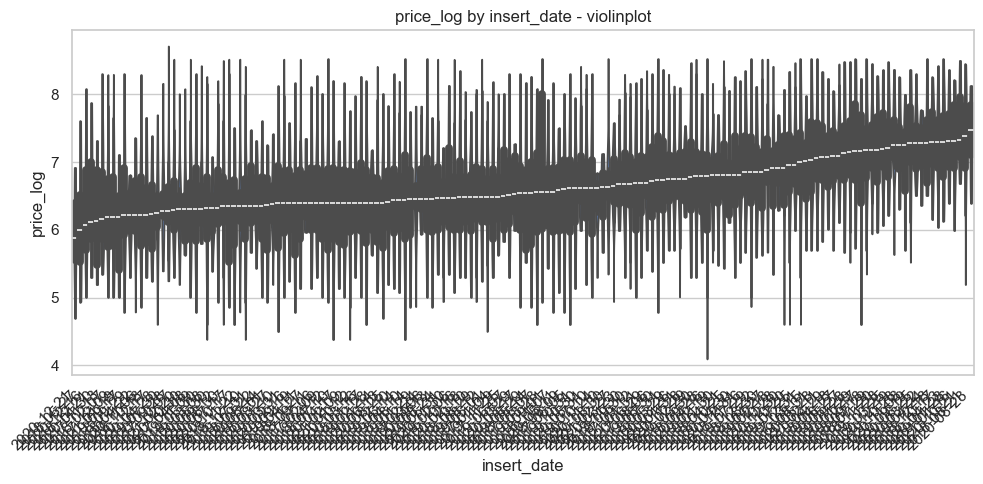


All tables and figures were saved to: F:\_LearningMaterials\BarcelonaActiva\Simulació Empresarial\eq29_alojturistico\ProjecteData\Equip_29\Scripts\outputs


In [27]:
report = price_analysis_report(alojamentos_df[['name', 'description', 
                                               'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'city', 'insert_date', 'price_log']])

In [31]:
print(alojamentos_df['availability_30'].mean(), alojamentos_df['availability_30'].median())
print(alojamentos_df['availability_60'].mean(), alojamentos_df['availability_60'].median())
print(alojamentos_df['availability_90'].mean(), alojamentos_df['availability_90'].median())
print(alojamentos_df['availability_365'].mean(), alojamentos_df['availability_365'].median())

12.291697608792514 10.0
27.424327937026586 26.0
44.29793554136344 46.0
187.39180157433537 188.0
